# FDCA — Walkthrough Part II (ATBD §3.4.2.14 – §3.4.2.18)

Este notebook recorre **Parte II** del algoritmo FDCA (WFABBA) sección por sección del ATBD,
llamando directamente a las funciones de producción de `fdca/part2.py`. 

**Escena de test:** `TIMESTAMP = 20250926_1900`, `region = uruguay` (misma escena que el
walkthrough de Part I).

**Orden de secciones:**
1. Setup — correr Part I real sobre la escena de test para obtener los candidatos de entrada
2. §3.4.2.14 (primera mitad) — Eliminación de falsas alarmas (`_eliminate_false_alarm`)
3. §3.4.2.14 (segunda mitad) — Reasignación de borde nube/glint (`_reassign_cloud_glint_edge`)
4. §3.4.2.15 (primera mitad) — Segundo test de borde de niebla (`_reassign_fog_edge`)
5. §3.4.2.15 (segunda mitad) — Upgrade de confianza alta/media (`_upgrade_confidence`)
6. §3.4.2.15 (categorización) — Asignación de categoría final (`_assign_fire_category`)
7. §3.4.2.16 — Filtrado temporal (real + demo sintética aparte)
8. §3.4.2.17 / §3.4.2.18 — Salida final, `run_part2()` end-to-end y mapa de resultado


## 0. Setup

Cargamos la escena de test con `fdca_adapter.load_fdca_input` y corremos `run_part1.run_part1`
de producción para obtener `fire_mask`, `fail_char_arr` y la lista real de `FireCandidate` que
entra a Part II. 

Por convención del proyecto, hacemos`copy.deepcopy(candidates)` y `fire_mask.copy()` antes de 
cualquier paso de Part II, para que cada sección de este notebook pueda experimentar libremente 
sin mutar el estado que usan las secciones siguientes como referencia "antes de Part II".


In [8]:
# ──  carga del repo  ───────────────────────────────────
import subprocess
import os
import sys
from pathlib import Path
try:
    from google.colab import userdata # Detectar si estamos en Google Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BRANCH = "testing-fdca-real"

if IN_COLAB:
    print("Ejecutando en Google Colab")

    GH_TOKEN = userdata.get("GITHUB_TOKEN")
    REPO_URL = f"https://{GH_TOKEN}@github.com/Vale23-23/GERIS-PFC.git"
    CLONE_DIR = "/content/GERIS-PFC"

    if not os.path.exists(CLONE_DIR):
        result = subprocess.run(
            [
                "git", "clone",
                "--branch", BRANCH,
                "--depth", "1",
                REPO_URL,
                CLONE_DIR
            ],
            capture_output=True,
            text=True
        )

        if result.returncode != 0:
            raise RuntimeError(result.stderr)

        print("Repo clonado OK")

    else:
        pull = subprocess.run(
            ["git", "-C", CLONE_DIR, "pull"],
            capture_output=True,
            text=True
        )
        print("Pull OK")

    PROJECT_ROOT = Path(CLONE_DIR) / "implementacion"

else:
    print("Ejecutando localmente (VS Code u otro IDE)")

    cwd = Path.cwd()
    if (cwd / "implementacion" / "fdca").exists():
        PROJECT_ROOT = cwd / "implementacion"
    elif (cwd / "fdca").exists():
        PROJECT_ROOT = cwd
    else:
        PROJECT_ROOT = cwd

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Ejecutando localmente (VS Code u otro IDE)
PROJECT_ROOT = /home/luciana/Escritorio/Fing/PFC/testing-fdca-real/implementacion


In [ ]:
# ──  imports y módulos del proyecto ───────────────────────────────────
import copy
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import json, warnings

from fdca.fdca_adapter import load_fdca_input
from fdca.constants import *
from fdca.state import PreviousFireMaskStore, scene_datetime_to_epoch, FIRE_CODES_FOR_STATE_UPDATE
from fdca.part1 import run_part1
import fdca.part2 as p2   

warnings.filterwarnings('ignore')

FAILCHAR_NAMES = {v: k for k, v in vars(FailChar).items() if not k.startswith("_") and isinstance(v, int)}
FIREMASK_NAMES = {v: k for k, v in vars(FireMask).items() if not k.startswith("_") and isinstance(v, int)}

print('Imports OK')

Imports OK


In [11]:
TIMESTAMP = "20250926_1900"
REGION = "uruguay"
DATASET_ROOT = "/home/luciana/Escritorio/Fing/PFC/GERIS-PFC/obtencion_imagenes/dataset"
CONFIG_PATH = str(PROJECT_ROOT / "fdca" / "config.yaml")

target_dt = datetime.strptime(TIMESTAMP, "%Y%m%d_%H%M")

# 12hs previas, cada 10 min, sin incluir el propio target
warmup_dts = []
t = target_dt - timedelta(hours=12)
while t < target_dt:
    warmup_dts.append(t)
    t += timedelta(minutes=10)

print(f"{len(warmup_dts)} timestamps de calentamiento: "
      f"{warmup_dts[0].strftime('%Y%m%d_%H%M')} -> {warmup_dts[-1].strftime('%Y%m%d_%H%M')}")

72 timestamps de calentamiento: 20250926_0700 -> 20250926_1850


In [4]:
path = "/home/luciana/Escritorio/Fing/PFC/GERIS-PFC/obtencion_imagenes/dataset/uruguay/ABI-L2-FDCF-Mask/20250926_1800.npy"

dqf = np.load(path).astype(np.uint8)

print("shape:", dqf.shape)
print("dtype:", dqf.dtype)
print("valores únicos:", np.unique(dqf))

values, counts = np.unique(dqf, return_counts=True)

for value, count in zip(values, counts):
    print(f"Valor {value}: {count} píxeles")

shape: (224, 303)
dtype: uint8
valores únicos: [ 10  13  15  30  32  33  34  35 100 150 153 200 215 220]
Valor 10: 2 píxeles
Valor 13: 1 píxeles
Valor 15: 2 píxeles
Valor 30: 82 píxeles
Valor 32: 1 píxeles
Valor 33: 11 píxeles
Valor 34: 1 píxeles
Valor 35: 8 píxeles
Valor 100: 66669 píxeles
Valor 150: 225 píxeles
Valor 153: 852 píxeles
Valor 200: 9 píxeles
Valor 215: 3 píxeles
Valor 220: 6 píxeles


In [12]:
STATE_PATH = "dataset/uruguay/prev_fire_mask.npy"
if os.path.exists(STATE_PATH):
    os.remove(STATE_PATH)

probe_path = f"{DATASET_ROOT}/{REGION}/ABI-L1b-Rad-B07/{TIMESTAMP}.npy"
probe_shape = np.load(probe_path).shape

prev_store = PreviousFireMaskStore(shape=probe_shape, path=STATE_PATH)

n_usados, n_saltados = 0, 0
for ts_dt in warmup_dts:
    ts = ts_dt.strftime("%Y%m%d_%H%M")
    mask_path = f"{DATASET_ROOT}/{REGION}/ABI-L2-FDCF-Mask/{ts}.npy"
    if not os.path.exists(mask_path):
        n_saltados += 1
        continue
    mask_vals = np.load(mask_path)
    fire_pixels = np.isin(mask_vals, FIRE_CODES_FOR_STATE_UPDATE)
    if not fire_pixels.any():
        continue
    prev_store.data = np.where(fire_pixels, scene_datetime_to_epoch(ts_dt), prev_store.data)
    n_usados += 1

prev_store.save()
print(f"Timestamps usados: {n_usados} | saltados/faltantes: {n_saltados}")
print(f"Pixeles con fuego previo registrado: {(prev_store.data > 0).sum()}")

Timestamps usados: 53 | saltados/faltantes: 0
Pixeles con fuego previo registrado: 346


In [13]:
#  ──  carga del input de esta escena ─────────────────────────
inp = load_fdca_input(
    timestamp=TIMESTAMP,
    region=REGION,
    config_path=CONFIG_PATH,
    dataset_root=DATASET_ROOT,
    verbose=True,
)
print(f"Grilla: {inp.bt7.shape}  |  BT7 [{np.nanmin(inp.bt7):.1f}, {np.nanmax(inp.bt7):.1f}] K")


  ABI-L1b-Rad-B07       : shape=(224, 303)  range=[0.58, 25.59]
  ABI-L1b-Rad-B14       : shape=(224, 303)  range=[75.79, 196.25]
  ABI-L1b-Rad-B13       : shape=(224, 303)  range=[66.67, 177.84]
  ABI-L1b-Rad-B15       : shape=(224, 303)  range=[75.24, 181.48]
  ABI-L1b-Rad-B02       : shape=(893, 1212)  range=[12.06, 344.00]

  SZA range [°]         : 48.0 – 55.9
  LZA range [°]         : 31.3 – 40.1
  Píxeles diurnos       : 100%

  BT7 range [K]         : 288.9 – 410.9
  BT14 range [K]        : 271.9 – 339.2
  refl2 range           : 0.029 – 0.273
  Emisividad            : CAMEL V3 clim. (CAM5K30EMCLIM_emis_climatology_09Month_V003.nc)
  TPW range [mm]        : 25.0 – 35.0  (estimación climatológica)

  ✓ FDCAInput construido — shape (224, 303)
Grilla: (224, 303)  |  BT7 [288.9, 410.9] K


In [14]:
#  ──  corrida de part1 ───────────────────────────────────
eco_mask = np.load("/home/luciana/Escritorio/Fing/PFC/testing-fdca-real/implementacion/mask_example.npy").astype(np.uint8)
fire_mask_p1, fail_char_p1, candidates_p1 = run_part1(
    bt7=inp.bt7, rad7=inp.rad7,
    bt14=inp.bt14, rad14=inp.rad14,
    bt13=inp.bt13, rad13=inp.rad13,
    bt15=inp.bt15,
    refl2=inp.refl2,
    latitudes=inp.latitudes, longitudes=inp.longitudes,
    sza=inp.sza, glint_angle=inp.glint_angle,
    lza=inp.lza, azimuth=inp.azimuth,
    tpw=inp.tpw, emiss7=inp.emiss7, emiss14=inp.emiss14,
    lut_tpw=inp.lut_tpw, FPT=inp.FPT,
    coeffs7=inp.coeffs7, coeffs14=inp.coeffs14, coeffs13=inp.coeffs13, land_mask=inp.land_mask,
    eco_mask = eco_mask, data_quality=inp.data_quality,
)

print(f"Candidatos que entran a Part II: {len(candidates_p1)}")
# Baseline congelado: todo lo que sigue trabaja sobre ESTAS copias
candidates_in = copy.deepcopy(candidates_p1)
fire_mask_in  = fire_mask_p1.copy()
fail_char_in  = fail_char_p1.copy()

Candidatos que entran a Part II: 542


In [ ]:
current_epoch = scene_datetime_to_epoch(target_dt)

fire_mask_out, fail_char_out, confirmed = run_part2(
    candidates, fire_mask, fail_char_arr,
    prev_fire_mask=prev_store.data,
    current_epoch=current_epoch,
)

print(f"Fuegos confirmados: {len(confirmed)}")

In [ ]:

STATE_PATH = "dataset/uruguay/prev_fire_mask.npy"
shape = _probe.bt7.shape   # o el shape que ya tengas a mano

prev_store = PreviousFireMaskStore(shape=shape, path=STATE_PATH)

for ts_dt in warmup_dts:   # los mismos 72 timestamps de antes
    ts = ts_dt.strftime("%Y%m%d_%H%M")
    mask_path = f"dataset/uruguay/ABI-L2-FDCF/{ts}.npy"
    if not os.path.exists(mask_path):
        continue

    dqf = np.load(mask_path).astype(np.int8)
    if np.all(dqf == 0):
        continue  # archivo inválido (región no procesada), no "todo fuego"

    fire_pixels = (dqf == 0)
    epoch = scene_datetime_to_epoch(ts_dt)
    prev_store.data = np.where(fire_pixels, epoch, prev_store.data)

prev_store.save()

## ATBD 3.4.2.14 a) — Eliminación de falsas alarmas

Una vez obtenida la lista de posibles fuegos, el algoritmo aplica pruebas adicionales para eliminar falsas alarmas. Si **cualquiera** de las tres pruebas siguientes es verdadera, el píxel se elimina como candidato a fuego:

- **cond1:** `T3.9 − Tb3.9 < 2.0` **Y** [`Refl − Reflb < Std.Dev.(Reflb) Part II` **O** along-scan test]
- **cond2:** `T3.9 < 290K + cos(SZA)·20` **Y** `T3.9 − Tb3.9 < 10` **Y** `T3.9 − T11.2 < 25K` **Y** [`Refl − Reflb < Std.Dev.(Reflb) Part II` **O** along-scan test]
- **cond3:** `T3.9 < 290K + cos(SZA)·20` **Y** `Tb3.9 < 280K + cos(SZA)·20` **Y** `n_passes ≥ 10` **Y** [`Refl − Reflb < Std.Dev.(Reflb) Part II` **O** along-scan test]

El `Std. Dev.(Reflb) Part II` es `max(2.5, 2.5 · σ_Refl_ventana)` (más laxo que el de Part I).
El along-scan test es el mismo de §3.4.2.4.


### 1.1 — Un candidato a mano

Elegimos el candidato con mayor `bt7_corr - bt7_bkg` (el "más caliente" respecto de fondo) para
ver el detalle de cada condición antes de aplicar la función de producción.


In [18]:
def std_reflb_part2(rad_diff_sigma: float) -> float:
    """
    Wrapper so the notebook can call the same formula as p2._
    std_reflb_part2 ithout relying on a name-mangled private import path.
    """
    return p2._std_reflb_part2(rad_diff_sigma)


sample = max(candidates_in, key=lambda c: (c.bt7_corr - c.bt7_bkg))
print(f"Candidato elegido: fire_id={sample.fire_id}  (i,j)=({sample.i},{sample.j})  fail_char={FAILCHAR_NAMES.get(sample.fail_char)}")
print()
print(f"  bt7           = {sample.bt7:.2f} K   (observado, sin corregir)")
print(f"  bt7_corr      = {sample.bt7_corr:.2f} K   (corregido: TPW+emis+solar+difraccion)")
print(f"  bt7_bkg       = {sample.bt7_bkg:.2f} K   (fondo, sin corregir)")
print(f"  bt_bkg_corr   = {sample.bt_bkg_corr:.2f} K   (fondo, corregido)")
print(f"  bt14          = {sample.bt14:.2f} K")
print(f"  bt14_corr     = {sample.bt14_corr:.2f} K")
print(f"  refl_pixel    = {sample.refl_pixel:.4f}   reflb = {sample.reflb:.4f}")
print(f"  rad_diff_sigma= {sample.rad_diff_sigma:.4f}")
print(f"  n_passes      = {sample.n_passes}")
print(f"  sza           = {sample.sza:.1f}°  is_day={sample.is_day}")

sza_cos = np.cos(np.radians(sample.sza))
day_off = sza_cos * P2_DAY_OFFSET_COEF if sample.is_day else 0.0
std_reflb_p2 = std_reflb_part2(sample.rad_diff_sigma)
refl_ok = (sample.refl_pixel - sample.reflb < std_reflb_p2) or sample.pass_along_scan

print(f"\n  day_off (cos(SZA)*{P2_DAY_OFFSET_COEF}) = {day_off:.2f}")
print(f"  Std.Dev.(Reflb) Part II = {std_reflb_p2:.4f}")
print(f"  refl_ok (Refl-Reflb < umbral OR along-scan) = {refl_ok}")


Candidato elegido: fire_id=211  (i,j)=(77,65)  fail_char=NONE

  bt7           = 410.92 K   (observado, sin corregir)
  bt7_corr      = 423.90 K   (corregido: TPW+emis+solar+difraccion)
  bt7_bkg       = 313.16 K   (fondo, sin corregir)
  bt_bkg_corr   = 314.46 K   (fondo, corregido)
  bt14          = 339.18 K
  bt14_corr     = 358.44 K
  refl_pixel    = 21.7378   reflb = 0.4299
  rad_diff_sigma= 0.1268
  n_passes      = 0
  sza           = 49.9°  is_day=True

  day_off (cos(SZA)*20.0) = 12.88
  Std.Dev.(Reflb) Part II = 2.5000
  refl_ok (Refl-Reflb < umbral OR along-scan) = True


In [19]:
# ── Manual evaluation with RAW temperatures (current part2.py behaviour) ──
raw_c1 = (sample.bt7 - sample.bt7_bkg < DELTA_BT7_TB7_MIN) and refl_ok
raw_c2 = (sample.bt7 < BT7_WARM_NIGHT + day_off
          and sample.bt7 - sample.bt7_bkg < DELTA_BT7_TB7_MAX
          and sample.bt7 - sample.bt14 < DELTA_BT7_BT14_MAX
          and refl_ok)
raw_c3 = (sample.bt7 < BT7_WARM_NIGHT + day_off
          and sample.bt7_bkg < TB7_COLD_NIGHT + day_off
          and sample.n_passes >= BKG_MAX_ITER
          and refl_ok)

print("── Con temperaturas SIN corregir (como hoy part2.py) ──")
print(f"  cond1 = {raw_c1}   cond2 = {raw_c2}   cond3 = {raw_c3}")
eliminated_raw, reason_raw = p2._eliminate_false_alarm(sample)
print(f"  _eliminate_false_alarm() de producción -> eliminado={eliminated_raw}  razon='{reason_raw}'")

# ── Manual evaluation with CORRECTED temperatures (ATBD-faithful) ──
corr_c1 = (sample.bt7_corr - sample.bt_bkg_corr < DELTA_BT7_TB7_MIN) and refl_ok
corr_c2 = (sample.bt7_corr < BT7_WARM_NIGHT + day_off
           and sample.bt7_corr - sample.bt_bkg_corr < DELTA_BT7_TB7_MAX
           and sample.bt7_corr - sample.bt14_corr < DELTA_BT7_BT14_MAX
           and refl_ok)
corr_c3 = (sample.bt7_corr < BT7_WARM_NIGHT + day_off
           and sample.bt_bkg_corr < TB7_COLD_NIGHT + day_off
           and sample.n_passes >= BKG_MAX_ITER
           and refl_ok)

print("\n── Con temperaturas CORREGIDAS (fiel al ATBD) ──")
print(f"  cond1 = {corr_c1}   cond2 = {corr_c2}   cond3 = {corr_c3}")
print(f"  eliminado (ATBD) = {corr_c1 or corr_c2 or corr_c3}")


── Con temperaturas SIN corregir (como hoy part2.py) ──
  cond1 = False   cond2 = False   cond3 = False
  _eliminate_false_alarm() de producción -> eliminado=False  razon=''

── Con temperaturas CORREGIDAS (fiel al ATBD) ──
  cond1 = False   cond2 = False   cond3 = False
  eliminado (ATBD) = False


### 1.2 — Vectorizado sobre todos los candidatos

Aplicamos `_eliminate_false_alarm` de producción (temperaturas sin corregir, comportamiento
actual de `part2.py`) a **todos** los candidatos, y en paralelo calculamos la versión ATBD
(corregida) manualmente con la misma fórmula que arriba, para comparar cuántos candidatos
cambian de resultado según qué set de temperaturas se use.


In [21]:
def eliminate_atbd(cand):
    """
    ATBD-faithful re-implementation using corrected BTs (bt7_corr / bt_bkg_corr / bt14_corr),
    mirroring p2._eliminate_false_alarm's structure exactly, only swapping which fields are read.
    """
    sza_cos = np.cos(np.radians(cand.sza))
    day_off = sza_cos * P2_DAY_OFFSET_COEF if cand.is_day else 0.0
    std_p2  = std_reflb_part2(cand.rad_diff_sigma)
    refl_ok = (cand.refl_pixel - cand.reflb < std_p2) or cand.pass_along_scan

    if (cand.bt7_corr - cand.bt_bkg_corr < DELTA_BT7_TB7_MIN) and refl_ok:
        return True, "cond1"
    if (cand.bt7_corr < BT7_WARM_NIGHT + day_off
            and cand.bt7_corr - cand.bt_bkg_corr < DELTA_BT7_TB7_MAX
            and cand.bt7_corr - cand.bt14_corr < DELTA_BT7_BT14_MAX
            and refl_ok):
        return True, "cond2"
    if (cand.bt7_corr < BT7_WARM_NIGHT + day_off
            and cand.bt_bkg_corr < TB7_COLD_NIGHT + day_off
            and cand.n_passes >= BKG_MAX_ITER
            and refl_ok):
        return True, "cond3"
    return False, ""


rows = []
for c in candidates_in:
    elim_raw,  reason_raw  = p2._eliminate_false_alarm(c)   # production function, as-is today
    elim_atbd, reason_atbd = eliminate_atbd(c)               # ATBD-faithful (corrected BTs)
    rows.append((c.fire_id, elim_raw, reason_raw, elim_atbd, reason_atbd))

n_elim_raw  = sum(1 for r in rows if r[1])
n_elim_atbd = sum(1 for r in rows if r[3])
n_disagree  = sum(1 for r in rows if r[1] != r[3])

print(f"Total candidatos              : {len(rows)}")
print(f"Eliminados (part2.py actual)  : {n_elim_raw}")
print(f"Eliminados (ATBD, corregidas) : {n_elim_atbd}")
print(f"Candidatos donde el resultado difiere entre ambas versiones: {n_disagree}")


Total candidatos              : 542
Eliminados (part2.py actual)  : 0
Eliminados (ATBD, corregidas) : 0
Candidatos donde el resultado difiere entre ambas versiones: 0


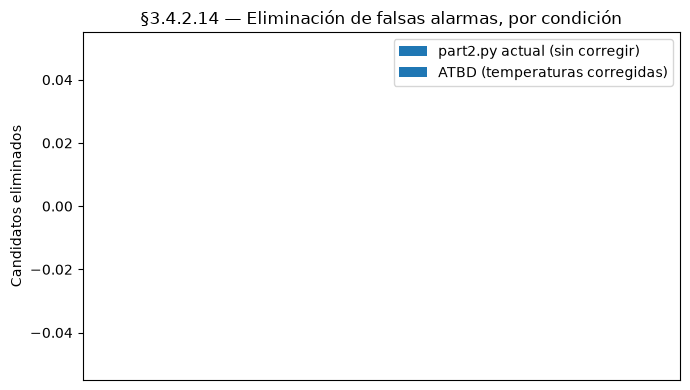

In [22]:
reason_counts_raw  = {}
reason_counts_atbd = {}
for _, elim_raw, reason_raw, elim_atbd, reason_atbd in rows:
    if elim_raw:
        reason_counts_raw[reason_raw] = reason_counts_raw.get(reason_raw, 0) + 1
    if elim_atbd:
        reason_counts_atbd[reason_atbd] = reason_counts_atbd.get(reason_atbd, 0) + 1

labels = sorted(set(reason_counts_raw) | set(reason_counts_atbd))
raw_vals  = [reason_counts_raw.get(l, 0)  for l in labels]
atbd_vals = [reason_counts_atbd.get(l, 0) for l in labels]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, raw_vals,  width, label="part2.py actual (sin corregir)", color="salmon")
ax.bar(x + width/2, atbd_vals, width, label="ATBD (temperaturas corregidas)", color="seagreen")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Candidatos eliminados")
ax.set_title("§3.4.2.14 — Eliminación de falsas alarmas, por condición")
ax.legend()
plt.tight_layout()
plt.show()


### 1.3 — Scatter de la condición dominante (cond1)

`bt7 − bt7_bkg` vs `refl − reflb` para todos los candidatos, coloreados por eliminado/sobreviviente
(según la versión ATBD con temperaturas corregidas), con las líneas de umbral dibujadas.


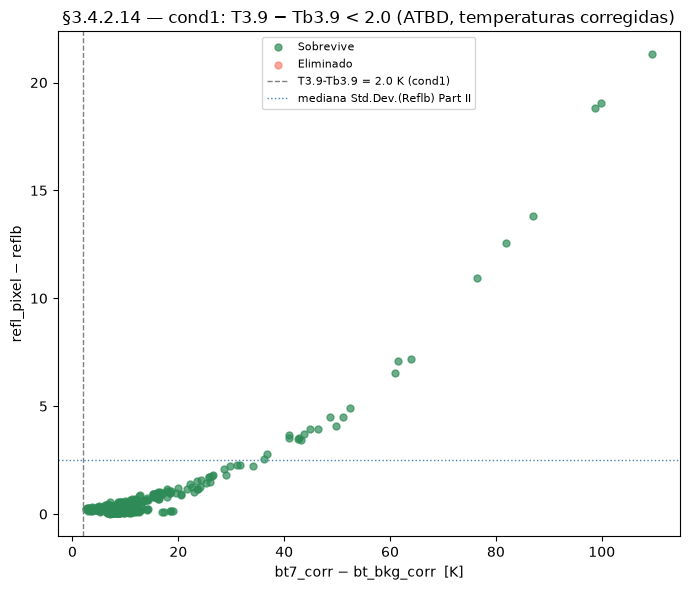

In [23]:
dx = np.array([c.bt7_corr - c.bt_bkg_corr for c in candidates_in])
dy = np.array([c.refl_pixel - c.reflb for c in candidates_in])
elim_mask = np.array([eliminate_atbd(c)[0] for c in candidates_in])
std_p2_vals = np.array([std_reflb_part2(c.rad_diff_sigma) for c in candidates_in])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(dx[~elim_mask], dy[~elim_mask], c="seagreen", label="Sobrevive", alpha=0.7, s=25)
ax.scatter(dx[elim_mask],  dy[elim_mask],  c="salmon",   label="Eliminado", alpha=0.7, s=25)
ax.axvline(DELTA_BT7_TB7_MIN, color="gray", linestyle="--", linewidth=1,
           label=f"T3.9-Tb3.9 = {DELTA_BT7_TB7_MIN} K (cond1)")
ax.axhline(np.median(std_p2_vals), color="steelblue", linestyle=":", linewidth=1,
           label="mediana Std.Dev.(Reflb) Part II")
ax.set_xlabel("bt7_corr − bt_bkg_corr  [K]")
ax.set_ylabel("refl_pixel − reflb")
ax.set_title("§3.4.2.14 — cond1: T3.9 − Tb3.9 < 2.0 (ATBD, temperaturas corregidas)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 2. §3.4.2.14 (segunda mitad) — Reasignación de borde nube/glint

**ATBD:** el algoritmo reevalúa posibles píxeles de fuego a lo largo del borde de nube/niebla.
Aplica solo a píxeles con flag "9" o "10" pasado desde Part I (`FailChar.F9` / `FailChar.F10`,
ver §3.4.2.8–3.4.2.9). El test:

- `Albedo > 0.25` **O** `Albedo − Albedo_fondo ≥ 0.10`
- **Y** `T3.9 < 292.5K + cos(SZA)·20`
- **Y** flag de Part I ∈ {9, 10}

Si se cumple, el flag se reasigna a `11` y el píxel sigue procesándose (ya no queda descartado
como "solo nube/glint" — pasa a competir por una categoría de fuego posible más adelante).

Esta parte usa `bt7_corr` (`cand.bt7_corr`), no la observada sin corregir — acá **sí** coincide
con el ATBD, es la función `_reassign_cloud_glint_edge` de producción tal cual está.


In [24]:
eligible_f9_f10 = [c for c in candidates_in if c.fail_char in (FailChar.F9, FailChar.F10)]
print(f"Candidatos con fail_char en {{F9, F10}} (elegibles para reasignar a F11): {len(eligible_f9_f10)}")

reassign_flags = []
for c in eligible_f9_f10:
    sza_cos = np.cos(np.radians(c.sza))
    day_off = sza_cos * P2_DAY_OFFSET_COEF if c.is_day else 0.0
    reassigned = p2._reassign_cloud_glint_edge(c, day_off)
    reassign_flags.append(reassigned)

n_reassigned = sum(reassign_flags)
print(f"Reasignados a F11 : {n_reassigned}  ({100*n_reassigned/max(1,len(eligible_f9_f10)):.0f}%)")


Candidatos con fail_char en {F9, F10} (elegibles para reasignar a F11): 300
Reasignados a F11 : 0  (0%)


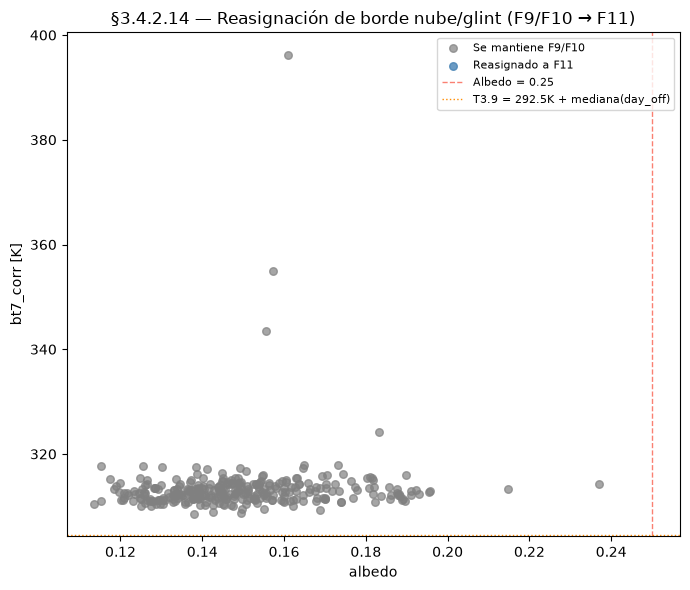

In [25]:
if eligible_f9_f10:
    albedo_vals   = np.array([c.albedo if not np.isnan(c.albedo) else 0.0 for c in eligible_f9_f10])
    bt7corr_vals  = np.array([c.bt7_corr for c in eligible_f9_f10])
    day_off_vals  = np.array([
        (np.cos(np.radians(c.sza)) * P2_DAY_OFFSET_COEF) if c.is_day else 0.0
        for c in eligible_f9_f10
    ])
    reassigned_arr = np.array(reassign_flags)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(albedo_vals[~reassigned_arr], bt7corr_vals[~reassigned_arr],
               c="gray", label="Se mantiene F9/F10", alpha=0.7, s=30)
    ax.scatter(albedo_vals[reassigned_arr], bt7corr_vals[reassigned_arr],
               c="steelblue", label="Reasignado a F11", alpha=0.8, s=30)
    ax.axvline(CLOUD_EDGE_ALBEDO_MIN, color="salmon", linestyle="--", linewidth=1,
               label=f"Albedo = {CLOUD_EDGE_ALBEDO_MIN}")
    # Umbral de temperatura depende de day_off por candidato; graficamos la mediana como referencia
    thr_ref = CLOUD_EDGE_BT7_MAX_NIGHT + np.median(day_off_vals)
    ax.axhline(thr_ref, color="darkorange", linestyle=":", linewidth=1,
               label=f"T3.9 = {CLOUD_EDGE_BT7_MAX_NIGHT}K + mediana(day_off)")
    ax.set_xlabel("albedo")
    ax.set_ylabel("bt7_corr [K]")
    ax.set_title("§3.4.2.14 — Reasignación de borde nube/glint (F9/F10 → F11)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No hay candidatos F9/F10 en esta escena — no hay nada que graficar para esta sección.")


## 3. §3.4.2.15 (primera mitad) — Segundo test de borde de niebla

**ATBD:** el flag "11" también se reasigna cuando, para cualquier candidato con flag ≥ "9",
se cumple:

- `cos(SZA)·20 + 5 − (Tb3.9 − Tb11.2) < 1.5`
- **Y** `T3.9 − Tb3.9 ≤ 4.0K`

A diferencia del test anterior, este aplica a **cualquier** flag ≥ 9 (no solo F9/F10 estrictos),
así que el conjunto elegible incluye también los que ya pasaron a F11 en la sección anterior.
La función de producción es `_reassign_fog_edge`.


In [26]:
eligible_ge_f9 = [c for c in candidates_in if c.fail_char >= FailChar.F9]
print(f"Candidatos con fail_char >= F9: {len(eligible_ge_f9)}")

fog_flags = []
for c in eligible_ge_f9:
    sza_cos = np.cos(np.radians(c.sza))
    reassigned = p2._reassign_fog_edge(c, sza_cos)
    fog_flags.append(reassigned)

n_fog = sum(fog_flags)
print(f"Reasignados a F11 por el test de niebla: {n_fog}  ({100*n_fog/max(1,len(eligible_ge_f9)):.0f}%)")


Candidatos con fail_char >= F9: 300
Reasignados a F11 por el test de niebla: 0  (0%)


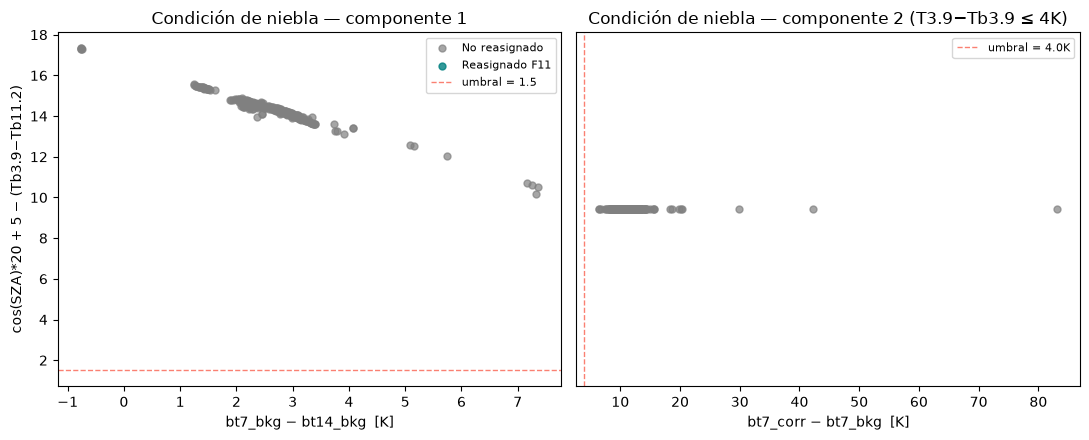

In [27]:
if eligible_ge_f9:
    bkg_diff  = np.array([c.bt7_bkg - c.bt14_bkg for c in eligible_ge_f9])
    delta_bt7 = np.array([c.bt7_corr - c.bt7_bkg for c in eligible_ge_f9])
    sza_cos_v = np.array([np.cos(np.radians(c.sza)) for c in eligible_ge_f9])
    fog_c1    = sza_cos_v * P2_DAY_OFFSET_COEF + 5.0 - bkg_diff
    fog_arr   = np.array(fog_flags)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].scatter(bkg_diff[~fog_arr], fog_c1[~fog_arr], c="gray", alpha=0.7, s=25, label="No reasignado")
    axes[0].scatter(bkg_diff[fog_arr],  fog_c1[fog_arr],  c="teal", alpha=0.8, s=25, label="Reasignado F11")
    axes[0].axhline(1.5, color="salmon", linestyle="--", linewidth=1, label="umbral = 1.5")
    axes[0].set_xlabel("bt7_bkg − bt14_bkg  [K]")
    axes[0].set_ylabel("cos(SZA)*20 + 5 − (Tb3.9−Tb11.2)")
    axes[0].set_title("Condición de niebla — componente 1")
    axes[0].legend(fontsize=8)

    axes[1].scatter(delta_bt7[~fog_arr], np.zeros(np.sum(~fog_arr)), c="gray", alpha=0.7, s=25)
    axes[1].scatter(delta_bt7[fog_arr],  np.zeros(np.sum(fog_arr)),  c="teal", alpha=0.8, s=25)
    axes[1].axvline(4.0, color="salmon", linestyle="--", linewidth=1, label="umbral = 4.0K")
    axes[1].set_xlabel("bt7_corr − bt7_bkg  [K]")
    axes[1].set_yticks([])
    axes[1].set_title("Condición de niebla — componente 2 (T3.9−Tb3.9 ≤ 4K)")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("No hay candidatos con fail_char >= F9 en esta escena.")


## 4. §3.4.2.15 (segunda mitad) — Upgrade de confianza alta/media

**ATBD:** para píxeles con flag ∈ {3, 4, 6, 8} el algoritmo suma 30 (alta) o 20 (media) al flag
si se cumple:

- `T3.9 − Tb3.9 > umbral1_{alta o media}`
- **Y** `Tb3.9 − Tb11.2 > umbral2_{alta o media}`
- **Y** [`Refl − Reflb ≥ Std.Dev.(Reflb) Part II` **O** along-scan test]

**Umbral 1** = `max(base, add_c + bg_off + 2·σ_bt7_bkg)`, con `base=7K / add_c=5` (alta) o
`base=5K / add_c=3` (media), `bg_off = min(5, n_passes/3)`.

**Umbral 2** = `max(base, add_c + bg_off + (Tb3.9−Tb11.2) + 2·σ_(bt7−bt14)_bkg)`, mismos `base`/`add_c`.

Sólo se evalúa si `fire_temp < 0` (Part I no encontró solución Dozier válida). Funciones de
producción: `_upgrade_confidence` + `_high_med_thresholds`.


In [28]:
eligible_upgrade = [
    c for c in candidates_in
    if c.fail_char in (FailChar.F3, FailChar.F4, FailChar.F6, FailChar.F8)
    and not np.isnan(c.fire_temp) and c.fire_temp < 0
]
print(f"Candidatos elegibles para upgrade de confianza (F3/F4/F6/F8, fire_temp<0): {len(eligible_upgrade)}")

upgrade_rows = []
for c in eligible_upgrade:
    fire_code, flag_delta = p2._upgrade_confidence(c)
    thr1_h, thr2_h = p2._high_med_thresholds(c, "high")
    thr1_m, thr2_m = p2._high_med_thresholds(c, "medium")
    upgrade_rows.append(dict(
        fire_id=c.fire_id,
        bt7_minus_tb7=c.bt7_corr - c.bt7_bkg,
        tb7_minus_tb14=c.bt7_bkg - c.bt14_bkg,
        thr1_h=thr1_h, thr2_h=thr2_h, thr1_m=thr1_m, thr2_m=thr2_m,
        result=FIREMASK_NAMES.get(fire_code, str(fire_code)) if fire_code is not None else "LOW (no upgrade)",
    ))

for r in upgrade_rows:
    print(f"  fire_id={r['fire_id']:<4} T3.9-Tb3.9={r['bt7_minus_tb7']:6.2f} (thr_h={r['thr1_h']:.1f}, thr_m={r['thr1_m']:.1f})  "
          f"Tb3.9-Tb11.2={r['tb7_minus_tb14']:6.2f} (thr_h={r['thr2_h']:.1f}, thr_m={r['thr2_m']:.1f})  -> {r['result']}")


Candidatos elegibles para upgrade de confianza (F3/F4/F6/F8, fire_temp<0): 195
  fire_id=3    T3.9-Tb3.9=  9.85 (thr_h=7.6, thr_m=5.6)  Tb3.9-Tb11.2=  2.93 (thr_h=9.6, thr_m=7.6)  -> LOW_PROB
  fire_id=5    T3.9-Tb3.9= 10.93 (thr_h=7.7, thr_m=5.7)  Tb3.9-Tb11.2=  2.85 (thr_h=9.5, thr_m=7.5)  -> LOW_PROB
  fire_id=7    T3.9-Tb3.9= 10.93 (thr_h=7.0, thr_m=5.0)  Tb3.9-Tb11.2=  5.31 (thr_h=13.8, thr_m=11.8)  -> LOW_PROB
  fire_id=8    T3.9-Tb3.9= 13.25 (thr_h=7.0, thr_m=5.0)  Tb3.9-Tb11.2=  5.32 (thr_h=13.8, thr_m=11.8)  -> LOW_PROB
  fire_id=9    T3.9-Tb3.9=  7.31 (thr_h=7.5, thr_m=5.5)  Tb3.9-Tb11.2=  5.15 (thr_h=13.7, thr_m=11.7)  -> LOW_PROB
  fire_id=12   T3.9-Tb3.9= 13.40 (thr_h=7.0, thr_m=5.0)  Tb3.9-Tb11.2=  5.20 (thr_h=13.8, thr_m=11.8)  -> LOW_PROB
  fire_id=14   T3.9-Tb3.9= 43.89 (thr_h=7.9, thr_m=5.9)  Tb3.9-Tb11.2=  5.04 (thr_h=13.7, thr_m=11.7)  -> LOW_PROB
  fire_id=15   T3.9-Tb3.9=  7.31 (thr_h=7.8, thr_m=5.8)  Tb3.9-Tb11.2=  5.04 (thr_h=13.7, thr_m=11.7)  -> LOW_PROB
  fir

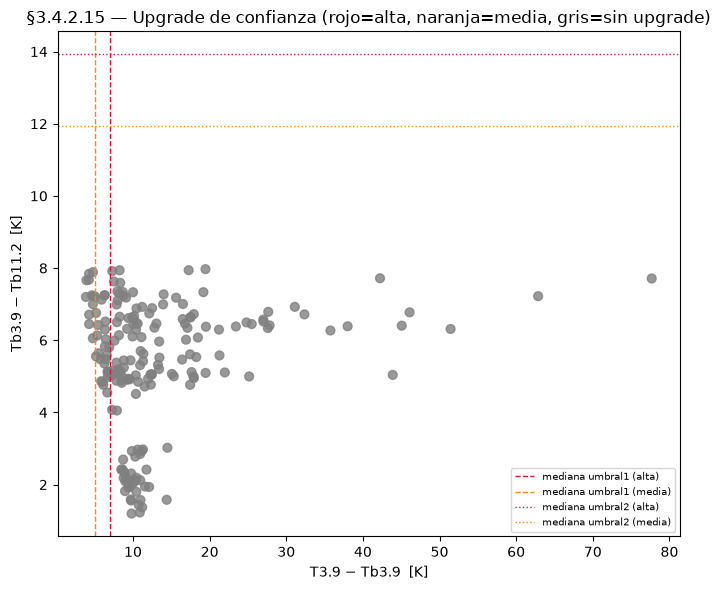

In [29]:
if upgrade_rows:
    x = np.array([r["bt7_minus_tb7"] for r in upgrade_rows])
    y = np.array([r["tb7_minus_tb14"] for r in upgrade_rows])
    thr1_h = np.array([r["thr1_h"] for r in upgrade_rows])
    thr2_h = np.array([r["thr2_h"] for r in upgrade_rows])
    thr1_m = np.array([r["thr1_m"] for r in upgrade_rows])
    thr2_m = np.array([r["thr2_m"] for r in upgrade_rows])
    result = np.array([r["result"] for r in upgrade_rows])

    color_map = {"HIGH_PROB": "crimson", "MED_PROB": "darkorange", "LOW (no upgrade)": "gray"}
    colors = [color_map.get(r, "gray") for r in result]

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(x, y, c=colors, s=40, alpha=0.8)
    # Cada candidato tiene su propio umbral (depende de n_passes y sigma de fondo) -> graficamos
    # la mediana de cada umbral como referencia visual, no como línea exacta por punto.
    ax.axvline(np.median(thr1_h), color="crimson",   linestyle="--", linewidth=1, label="mediana umbral1 (alta)")
    ax.axvline(np.median(thr1_m), color="darkorange", linestyle="--", linewidth=1, label="mediana umbral1 (media)")
    ax.axhline(np.median(thr2_h), color="crimson",   linestyle=":",  linewidth=1, label="mediana umbral2 (alta)")
    ax.axhline(np.median(thr2_m), color="darkorange", linestyle=":",  linewidth=1, label="mediana umbral2 (media)")
    ax.set_xlabel("T3.9 − Tb3.9  [K]")
    ax.set_ylabel("Tb3.9 − Tb11.2  [K]")
    ax.set_title("§3.4.2.15 — Upgrade de confianza (rojo=alta, naranja=media, gris=sin upgrade)")
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("No hay candidatos elegibles para upgrade de confianza en esta escena.")


## 5. §3.4.2.15 — Categorización final de fuego (códigos 10–15 / 30–35)

**ATBD** define las categorías (antes del filtrado temporal §3.4.2.16):

| Código | Categoría |
|---|---|
| 10 | Procesado (subpíxel: tamaño + temperatura), `Tt > 400K` |
| 11 | Fuego saturado (`Tt == 0`, Part I no intentó Dozier) |
| 12 | Parcialmente nublado / humo (flag "9" o "10") |
| 13 | Alta probabilidad (flag entre 30-40, `Tt < 0`) |
| 14 | Media probabilidad (flag entre 20-30, `Tt < 0`) |
| 15 | Baja probabilidad (flag "11" o < 9, `Tt < 0`) |

Los códigos 30-35 son los mismos, pero para fuegos que **sí** pasaron el filtro temporal
(§3.4.2.16, sección siguiente). Acá mostramos la categorización *antes* de ese filtro,
combinando `_assign_fire_category` + `_upgrade_confidence` tal como lo hace `run_part2`.


In [31]:
category_counts = {}
for c in candidates_in:
    fire_code = p2._assign_fire_category(c, fire_mask_in)
    upgraded_code, _ = p2._upgrade_confidence(c)
    if upgraded_code is not None:
        fire_code = upgraded_code
    name = FIREMASK_NAMES.get(fire_code, str(fire_code))
    category_counts[name] = category_counts.get(name, 0) + 1

print(f"§3.4.2.15 — Categoría de fuego (pre-filtro temporal) — {TIMESTAMP}")
for name, n in sorted(category_counts.items(), key=lambda kv: -kv[1]):
    print(f"  {name:<15} {n}")


§3.4.2.15 — Categoría de fuego (pre-filtro temporal) — 20250926_1900
  CLOUD_CONTAM    300
  LOW_PROB        195
  PROCESSED       47


## ATBD 3.4.2.16 — Filtrado temporal

La salida de Part II incluye fuegos sin filtrar y filtrados temporalmente. Para el
filtrado, cada píxel de fuego actual se compara contra una máscara con el tiempo (en segundos
desde el 1 de enero de 2001) del último fuego detectado en esa ubicación de grilla fija. Si hubo
un fuego previo dentro de las **últimas 12 horas** y dentro de **1 línea y 1 elemento** de
distancia, el píxel recibe un código indicando que es un fuego temporalmente filtrado
(offset +20 sobre el código base: 10→30, 11→31, ..., 15→35).

### 6.1 — Con dato real (`prev_fire_mask=None`)

In [38]:
fire_mask_temporal_none = fire_mask_in.copy()
fail_char_temporal_none = fail_char_in.copy()
cands_temporal_none     = copy.deepcopy(candidates_in)

current_epoch = scene_datetime_to_epoch(target_dt)   # reusar esta variable en las celdas siguientes

fire_mask_none, fail_char_none, confirmed_none = p2.run_part2(
    candidates=cands_temporal_none,
    fire_mask=fire_mask_temporal_none,
    fail_char_arr=fail_char_temporal_none,
    prev_fire_mask=None,
    current_epoch=current_epoch,
)

n_temporal = sum(1 for c in confirmed_none if fire_mask_none[c.i, c.j] >= 30)
print(f"Confirmados sin máscara previa: {len(confirmed_none)}")
print(f"Marcados como filtrados temporalmente (>=30): {n_temporal}  (esperado: 0, prev_fire_mask=None)")

Confirmados sin máscara previa: 542
Marcados como filtrados temporalmente (>=30): 0  (esperado: 0, prev_fire_mask=None)


## ATBD 3.4.2.17 / 3.4.2.18 — Salida final

La salida del algoritmo de fuego se describe en detalle en 3.4.3 — máscara
de códigos por píxel (Tabla 3.11), tamaño/temperatura/FRP subpíxel para fuegos "procesados",
máscara de "último fuego visto" para el filtro temporal, flags de QA, y metadata.

Se cierran los archivos de salida y termina el procesamiento.

Acá corremos `run_part2()` de producción **de punta a punta** sobre una copia fresca de los
candidatos de entrada (con `prev_fire_mask=None`, dato real disponible hoy), y verificamos 
que el resultado coincide con lo reconstruido paso a paso en las secciones 1-5.


In [ ]:
fire_mask_final = fire_mask_in.copy()
fail_char_final = fail_char_in.copy()
cands_final     = copy.deepcopy(candidates_in)

fire_mask_out, fail_char_out, confirmed_final = p2.run_part2(
    candidates=cands_final,
    fire_mask=fire_mask_final,
    fail_char_arr=fail_char_final,
    prev_fire_mask=None,
    current_epoch=current_epoch,
)

print(f"Total candidatos que entraron a Part II : {len(candidates_in)}")
print(f"Confirmados como fuego tras Part II      : {len(confirmed_final)}")
print(f"Eliminados en §3.4.2.14                  : {len(candidates_in) - len(confirmed_final)}")

final_category_counts = {}
for c in confirmed_final:
    name = FIREMASK_NAMES.get(fire_mask_out[c.i, c.j], str(fire_mask_out[c.i, c.j]))
    final_category_counts[name] = final_category_counts.get(name, 0) + 1

print("\nDistribucion final de categorias:")
for name, n in sorted(final_category_counts.items(), key=lambda kv: -kv[1]):
    print(f"  {name:<15} {n}")



Total candidatos que entraron a Part II : 542
Confirmados como fuego tras Part II      : 542
Eliminados en §3.4.2.14                  : 0


In [40]:
# ── Coherence check against the step-by-step reconstruction (section 5) ──
# category_counts (section 5) was computed BEFORE the temporal filter, so we compare
# against the pre-temporal-filter category rather than fire_mask_out directly.
mismatch = 0
for c in confirmed_final:
    step_by_step_code = p2._assign_fire_category(c, fire_mask_in)
    upgraded_code, _ = p2._upgrade_confidence(c)
    if upgraded_code is not None:
        step_by_step_code = upgraded_code
    # fire_mask_out may carry a +20 temporal offset; strip it before comparing
    end_to_end_code = fire_mask_out[c.i, c.j]
    end_to_end_base = end_to_end_code - 20 if end_to_end_code >= 30 else end_to_end_code
    if step_by_step_code != end_to_end_base:
        mismatch += 1

print(f"Candidatos confirmados cuya categoria base difiere entre reconstruccion paso a paso "
      f"y run_part2() end-to-end: {mismatch}  (esperado: 0)")


Candidatos confirmados cuya categoria base difiere entre reconstruccion paso a paso y run_part2() end-to-end: 0  (esperado: 0)


### 7.1 — Mapa final: máscara de fuego sobre BT7

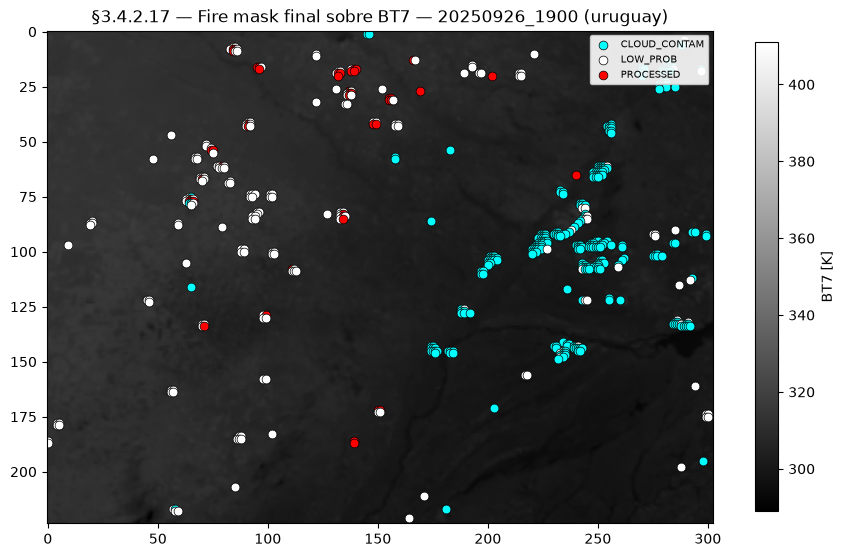

In [41]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(inp.bt7, cmap="gray", origin="upper")
plt.colorbar(im, ax=ax, label="BT7 [K]", shrink=0.7)

category_colors = {
    "PROCESSED":   "red",
    "SATURATED":   "purple",
    "CLOUD_CONTAM":"cyan",
    "HIGH_PROB":   "orange",
    "MED_PROB":    "yellow",
    "LOW_PROB":    "white",
}

plotted_labels = set()
for c in confirmed_final:
    code_val = fire_mask_out[c.i, c.j]
    base_val = code_val - 20 if code_val >= 30 else code_val
    name = FIREMASK_NAMES.get(base_val, str(base_val))
    color = category_colors.get(name, "lime")
    label = name if name not in plotted_labels else None
    plotted_labels.add(name)
    marker = "^" if code_val >= 30 else "o"  # triangle = temporally filtered
    ax.scatter(c.j, c.i, c=color, s=40, marker=marker, edgecolors="black", linewidths=0.5, label=label)

ax.set_title(f"§3.4.2.17 — Fire mask final sobre BT7 — {TIMESTAMP} ({REGION})")
ax.legend(loc="upper right", fontsize=7, framealpha=0.9)
plt.tight_layout()
plt.show()
